# Mouse 1 — brain sections with the FUS target regions

This notebook opens the Mouse 1 fluorescence scans and draws the six sonication targets on
top of them, labelled with target number, exposure, and measured GFP coverage.

**You need**

- the sections exported from the slide scanner (≈20 s each):
  `PYTHONPATH=src python -m fus.histology export data/histology/Mouse_01/Image.vsi data/processed/histology/Mouse_01/ds4`
- for section 5 only, the saved per-section results:
  `PYTHONPATH=src python -m fus.histology measure data/processed/histology/Mouse_01/ds4/section_s*.ome.tif --csv results/histology/mouse01_slots.csv`

**Background.** The sections are *horizontal* (top-down) slices, and all six targets sit at
the same depth, so each section crosses all six. Where the targets land is found by fitting
the known six-target pattern to the GFP signal. Method: [`docs/histology-pipeline.md`](../docs/histology-pipeline.md).
Assumptions behind the target labels: [`docs/mouse01-dose-delivery.md`](../docs/mouse01-dose-delivery.md).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patheffects
from matplotlib.patches import Circle

from fus import histology as h

plt.rcParams["figure.dpi"] = 90
%config InlineBackend.figure_formats = ["jpeg"]  # keeps the saved notebook small

SECTIONS = sorted((ROOT / "data/processed/histology/Mouse_01/ds4").glob("section_s*.ome.tif"))
[p.name for p in SECTIONS]

['section_s2.ome.tif',
 'section_s3.ome.tif',
 'section_s4.ome.tif',
 'section_s5.ome.tif',
 'section_s6.ome.tif']

## 1. Open a section

Each exported file is a pyramid. Level 0 is 1.3 µm/px (a few hundred MB per section);
every level above halves the resolution. Level 3 (~10 µm/px) loads instantly and is enough to
see the whole section.

In [2]:
preview = h.load_section(SECTIONS[0], level=3)
print(preview.name, preview.shape, f"{preview.pixel_um:.1f} µm/px")
print("channels:", list(preview.channels))

section_s2 (1033, 1165) 10.4 µm/px
channels: ['DAPI', 'FITC', 'TRITC', 'CY5']


| Channel | What it shows |
|---|---|
| `DAPI` | all cell nuclei |
| `FITC` | GFP, native fluorescence |
| `TRITC` | GFP, amplified with an anti-GFP antibody — **used as the delivery measure** |
| `CY5` | NeuN, neuronal nuclei — good for seeing anatomy |

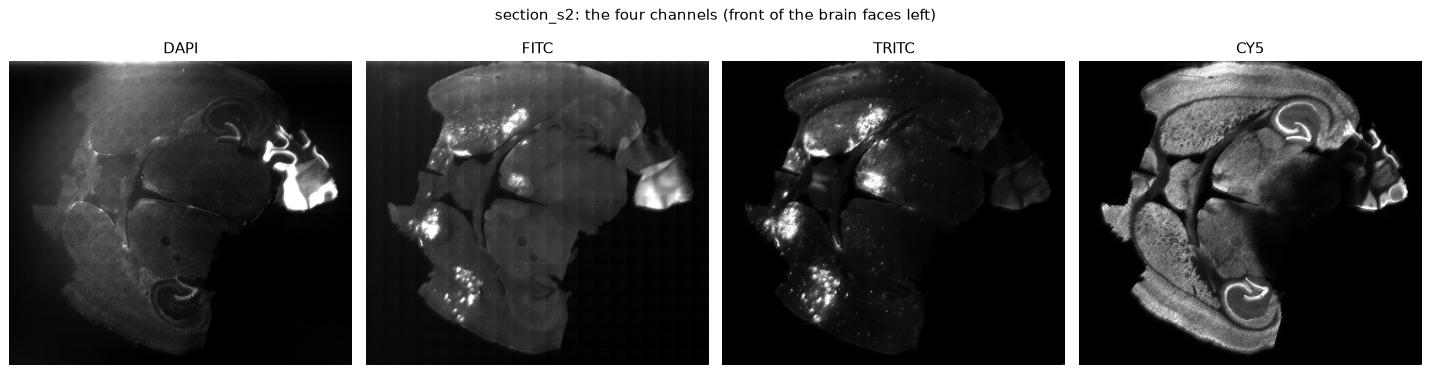

In [3]:
def stretch(a, lo=1, hi=99.5):
    """Scale an image to 0-1 between two percentiles."""
    a = a.astype(np.float32)
    p1, p2 = np.percentile(a, [lo, hi])
    return np.clip((a - p1) / (p2 - p1 + 1e-9), 0, 1)


fig, axes = plt.subplots(1, 4, figsize=(16, 4.4))
for ax, (name, img) in zip(axes, preview.channels.items()):
    ax.imshow(stretch(img), cmap="gray")
    ax.set_title(name)
    ax.axis("off")
fig.suptitle(f"{preview.name}: the four channels (front of the brain faces left)")
plt.tight_layout()

## 2. A colour composite

Neurons (NeuN) in magenta and GFP in green make the delivery sites easy to see against
the anatomy. Here are all five sections.

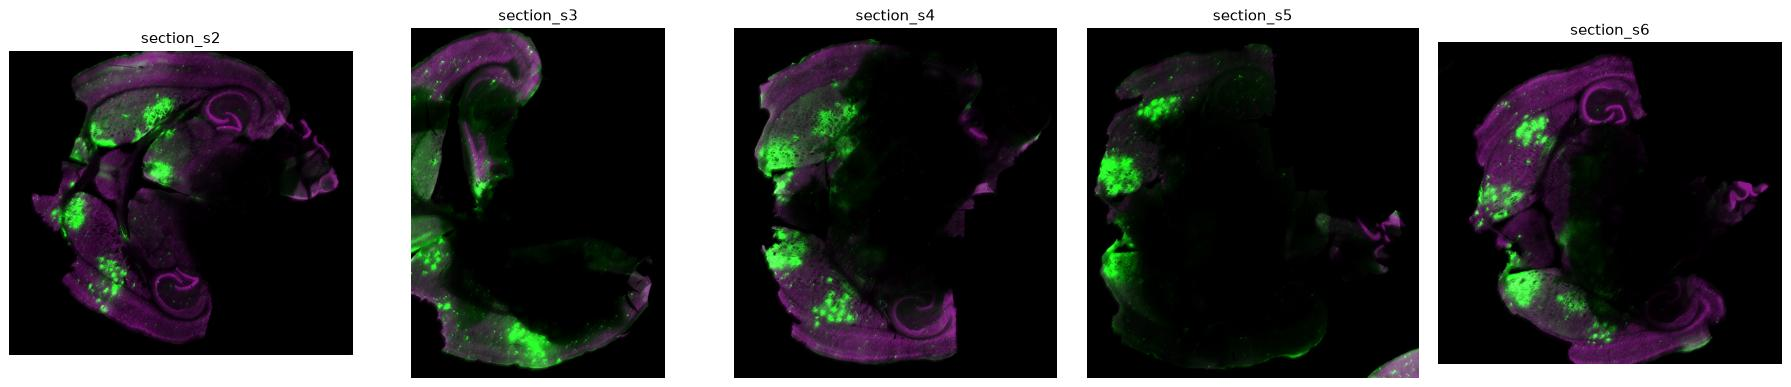

In [4]:
def composite(sec, gfp="TRITC"):
    """NeuN in dim magenta, GFP in green, on black."""
    n = stretch(sec.channels["CY5"]) ** 1.2 * 0.55
    g = stretch(sec.channels[gfp], 60, 99.5)
    return np.clip(np.dstack([n, g + 0.15 * n, n]), 0, 1)


previews = {p.name.split(".")[0]: h.load_section(p, level=3) for p in SECTIONS}

fig, axes = plt.subplots(1, len(previews), figsize=(4 * len(previews), 4.4))
for ax, (name, sec) in zip(axes, previews.items()):
    ax.imshow(composite(sec))
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()

## 3. The target plan, and which side is which

Every recording stores the same plan: six targets, in mm, as *(left–right, front–back)*.
The pattern is mirror-symmetric (1↔4, 2↔5, 3↔6), and the sections were not all mounted
the same way up, so the pipeline reports **slots** and converts them to targets with a
per-section *mirrored* flag.

The flags below and the exposure labels are **assumptions** (A1, A2 and the slide-deck
mapping in `docs/mouse01-dose-delivery.md`). Section s3 is only half a section and its
fit fails, so it has no flag.

In [5]:
plan = pd.DataFrame(h.PLAN_MM, index=["x_mm (left-right)", "y_mm (front-back)"]).T
plan.index.name = "target"

MIRRORED = {"section_s2": False, "section_s4": False, "section_s5": True, "section_s6": True}

EXPOSURE = {  # from the slide deck
    1: "3 sonications (420 bursts)",
    2: "45 bursts, goal 1.05",
    3: "no FUS (control)",
    4: "90 bursts, goal 0.95",
    5: "60 bursts, goal 0.85",
    6: "240 bursts, goal 0.55",
}
plan.assign(exposure=pd.Series(EXPOSURE))

,x_mm (left-right),y_mm (front-back),exposure
target,,,
1,1.5,5.0,3 sonications (420 bursts)
2,3.5,3.0,"45 bursts, goal 1.05"
3,1.5,2.5,no FUS (control)
4,-1.5,5.0,"90 bursts, goal 0.95"
5,-3.5,3.0,"60 bursts, goal 0.85"
6,-1.5,2.5,"240 bursts, goal 0.55"


## 4. Find the targets on one section

`analyse_section` does the whole measurement on the full-resolution image (≈10 s):
tissue mask → background removal → GFP+ pixels → fit the six-target pattern → coverage in
a 1.5 mm circle at each target. Each target's circle is placed using the *other five*
targets, so its own GFP can't pull the circle onto itself.

In [6]:
SECTION = "section_s4"

full = h.load_section(next(p for p in SECTIONS if p.name.startswith(SECTION)))
result = h.analyse_section(full)
table = result.table()

print(f"fit: rotated {result.full_fit.angle_deg:.0f}°, tissue shrinkage {result.full_fit.scale:.2f}")
table.pivot(index="slot", columns="channel", values="coverage").round(3)

fit: rotated 91°, tissue shrinkage 0.82


channel,FITC,TRITC
slot,,
1,0.501,0.896
2,0.456,0.768
3,0.000,0.012
4,0.153,0.478
5,0.318,0.398
6,0.830,0.036


Now draw the targets on the section. Circle positions are in full-resolution pixels,
so they are divided by the preview's downsampling factor. The control target gets a dashed
circle.

,exposure,coverage,tissue_fraction
target,,,
1,3 sonications (420 bursts),0.896,0.989
2,"45 bursts, goal 1.05",0.768,1.000
3,no FUS (control),0.012,1.000
4,"90 bursts, goal 0.95",0.478,1.000
5,"60 bursts, goal 0.85",0.398,1.000
6,"240 bursts, goal 0.55",0.036,1.000


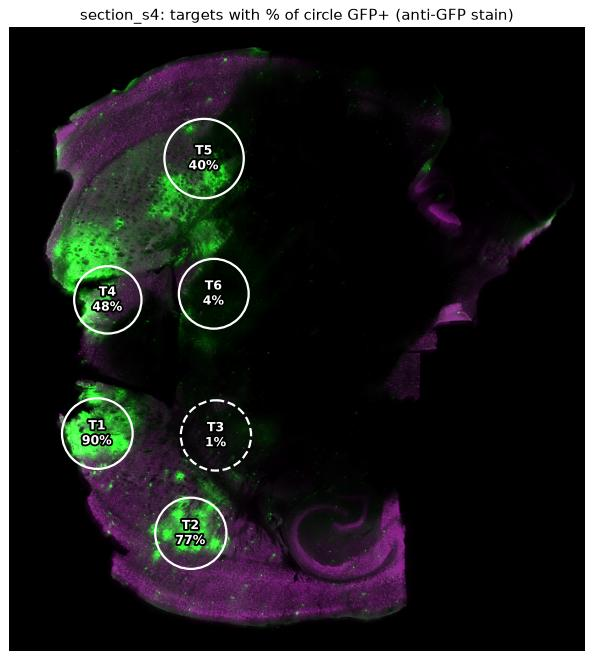

In [7]:
HALO = [patheffects.withStroke(linewidth=3, foreground="black")]


def draw_targets(ax, rois, bin_factor, mirrored=None, coverage=None):
    """Circle and label each target.

    rois: one row per slot with row, col, radius_px in full-resolution pixels.
    mirrored: the section's orientation flag, or None to label slots (S1-S6) instead.
    coverage: optional {slot: fraction} printed under the label.
    """
    for r in rois.itertuples():
        x = (r.col + 0.5) / bin_factor - 0.5
        y = (r.row + 0.5) / bin_factor - 0.5
        if mirrored is None:
            label, dashed = f"S{r.slot}", False
        else:
            target = h.slot_to_target(r.slot, mirrored)
            label, dashed = f"T{target}", target == 3
        if coverage is not None:
            label += f"\n{coverage[r.slot]:.0%}"
        ax.add_patch(Circle((x, y), r.radius_px / bin_factor, fill=False,
                            ec="white", lw=1.8, ls="--" if dashed else "-"))
        ax.text(x, y, label, color="white", ha="center", va="center",
                fontsize=10, weight="bold", path_effects=HALO)


rois = table[table.channel == "TRITC"].set_index("slot", drop=False)
sec = previews[SECTION]
bin_factor = sec.pixel_um / full.pixel_um  # preview px per full-resolution px

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(composite(sec))
draw_targets(ax, rois, bin_factor, MIRRORED[SECTION], coverage=rois["coverage"])
ax.set_title(f"{SECTION}: targets with % of circle GFP+ (anti-GFP stain)")
ax.axis("off")

labels = rois.assign(target=[h.slot_to_target(s, MIRRORED[SECTION]) for s in rois.slot])
labels.assign(exposure=labels.target.map(EXPOSURE))[["target", "exposure", "coverage", "tissue_fraction"]] \
    .set_index("target").sort_index().round(3)

## 5. All sections, from the saved results

Re-running the analysis for every section takes about a minute, so this uses the CSV that
`python -m fus.histology measure` wrote. s3 is shown with slot labels only, because its fit failed.

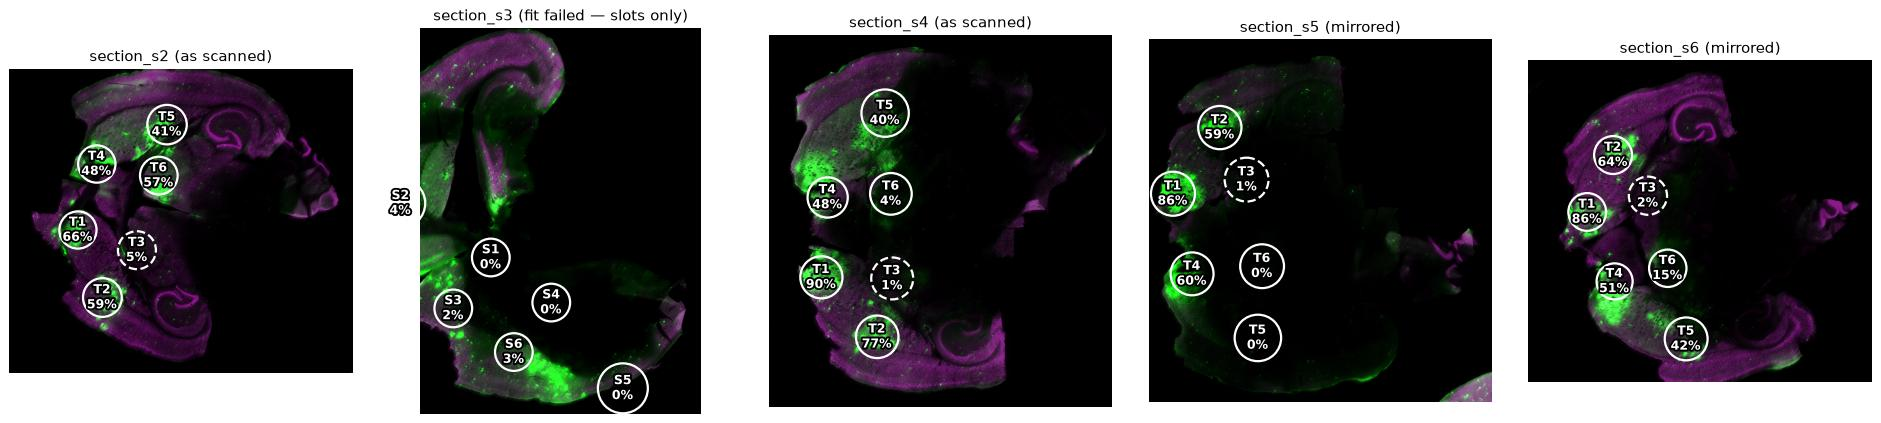

In [8]:
saved = pd.read_csv(ROOT / "results/histology/mouse01_slots.csv")

fig, axes = plt.subplots(1, len(previews), figsize=(4.2 * len(previews), 4.8))
for ax, (name, sec) in zip(axes, previews.items()):
    rows = saved[(saved.section == name) & (saved.channel == "TRITC")].set_index("slot", drop=False)
    ax.imshow(composite(sec))
    ax.axis("off")
    if rows.empty:
        ax.set_title(f"{name}: not measured")
        continue
    bin_factor = sec.pixel_um / full.pixel_um  # preview px per full-resolution px
    draw_targets(ax, rows, bin_factor, MIRRORED.get(name), coverage=rows["coverage"])
    status = "mirrored" if MIRRORED.get(name) else ("as scanned" if name in MIRRORED else "fit failed — slots only")
    ax.set_title(f"{name} ({status})")
plt.tight_layout()

## 6. Zoom in at full resolution

Close-ups of the sonicated target 1 and the no-FUS control (target 3) on the section
analysed in step 4, 2.4 mm across.

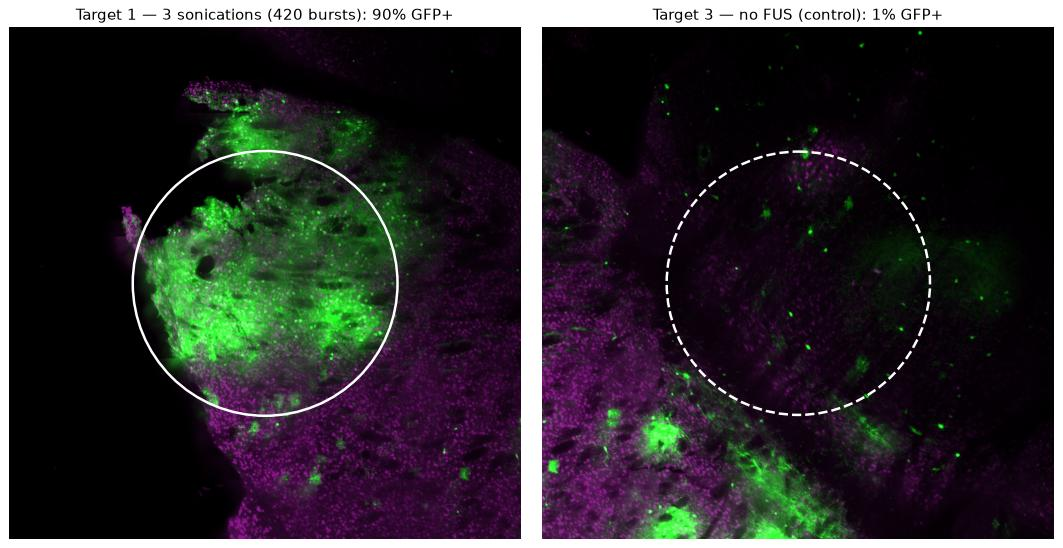

In [9]:
def crop_around(sec, row, col, half_mm=1.2):
    half = int(half_mm * 1000 / sec.pixel_um)
    r0, c0 = max(int(row) - half, 0), max(int(col) - half, 0)
    window = np.s_[r0:int(row) + half, c0:int(col) + half]
    cropped = h.Section(sec.path, {k: v[window] for k, v in sec.channels.items()}, sec.pixel_um)
    return cropped, r0, c0


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, target in zip(axes, (1, 3)):
    slot = next(s for s in rois.slot if h.slot_to_target(s, MIRRORED[SECTION]) == target)
    r = rois.loc[slot]
    cropped, r0, c0 = crop_around(full, r.row, r.col)
    ax.imshow(composite(cropped))
    ax.add_patch(Circle((r.col - c0, r.row - r0), r.radius_px, fill=False, ec="white",
                        lw=2, ls="--" if target == 3 else "-"))
    ax.set_title(f"Target {target} — {EXPOSURE[target]}: {r.coverage:.0%} GFP+")
    ax.axis("off")
plt.tight_layout()

## 7. Optional: explore interactively in napari

Set `OPEN_NAPARI = True` to open the full-resolution section in a separate
[napari](https://napari.org) window, with each channel as a layer and the targets as labelled
circles. Pan, zoom, and toggle channels there.

In [10]:
OPEN_NAPARI = True

if OPEN_NAPARI:
    import napari

    viewer = napari.Viewer(title=SECTION)
    for ch, cmap in [("CY5", "magenta"), ("TRITC", "green"), ("FITC", "yellow"), ("DAPI", "blue")]:
        viewer.add_image(full.channels[ch], name=ch, colormap=cmap, blending="additive",
                         visible=ch in ("CY5", "TRITC"))
    boxes, names = [], []
    for r in rois.itertuples():
        R = r.radius_px
        boxes.append([[r.row - R, r.col - R], [r.row - R, r.col + R],
                      [r.row + R, r.col + R], [r.row + R, r.col - R]])
        target = h.slot_to_target(r.slot, MIRRORED[SECTION])
        names.append(f"T{target} {r.coverage:.0%}")
    viewer.add_shapes(boxes, shape_type="ellipse", name="targets", edge_color="white",
                      face_color="transparent", edge_width=8,
                      features={"label": names},
                      text={"string": "{label}", "color": "white", "size": 14})

## Notes

- **Target labels are provisional.** They depend on each section's orientation and on the
  slide deck's no-FUS control. Change `MIRRORED` or `EXPOSURE` above if those turn out
  different.
- **Two GFP channels.** Swap `gfp="FITC"` into `composite` to see native GFP. The channels
  disagree at one target; see `docs/mouse01-dose-delivery.md`, section 2g.
- **Other animals.** Point `SECTIONS` at another export folder. The orientation flags will
  need to be worked out again for each animal.